# 16 - Witness Builder and Decision-Ready Paths

In the previous notebook, we explored the structure of individual certificates. In this notebook, we look at the **Witness Builder**—the orchestration layer that collects intermediate evidence and constructs a "decision-ready" path toward a homeomorphism proof.

A witness is not just a collection of facts; it is a **validated state machine**. We track the progression from "homology-only" data to "surgery-complete" status.

## Learning Goals
- **Collect Evidence Programmatically**: Use the `build_homeomorphism_witness` API to aggregate multi-scale invariants.
- **Track Status Progression**: Understand how a classification task move from `inconclusive` to `success`.
- **Decision-Ready Paths**: Identify when a manifold pair is ready for top-level classification.
- **High-Dim vs Low-Dim Patterns**: Compare the requirements for a "ready" witness across different dimensions.
- **Visualize Witness Completeness**: Monitor the accumulation of "Certified" flags in the result object.

## Formal Grounding

### The Witness Builder Lifecycle
The process of building a witness follows a strictly defined escalation path:
1. **Homology Level**: Verification of Betti numbers and torsion.
2. **Ring Level**: (Optional for $n<4$) Verification of cup products and intersection forms.
3. **Surgery Level**: (Required for $n \ge 5$) Verification of fundamental groups and Wall obstructions.
4. **Certificate Level**: Final assembly into a `HomeomorphismWitness`.

| Milestone | Data Required | Status |
|---|---|---|
| **Homology** | $H_*(M)$ | `inconclusive` |
| **Quadratic** | $Q_M$, $w_2$ | `decision_ready` (4D) |
| **Wall** | $L_n(\pi_1)$, $Wh(\pi_1)$ | `decision_ready` (5D+) |
| **Witness** | Valid Theorem Tag | `success` |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pysurgery as ps
from pysurgery.homeomorphism_witness import build_homeomorphism_witness

print('=' * 70)
print('16 - Witness Builder: Setup Complete')
print('=' * 70)

16 - Witness Builder: Setup Complete


## Part 1: Witness Status Progression

We demonstrate how adding data to the `build_homeomorphism_witness` function changes the result status.


### Example 16.1: Starting with Partial Evidence

In [2]:
# Suppose we only have homology data for two 4D manifolds
# (Mocking complexes)
c1 = ps.SimplicialComplex.from_maximal_simplices([(0,1,2,3,4)]).cellular_chain_complex()
c2 = ps.SimplicialComplex.from_maximal_simplices([(0,1,2,3,4)]).cellular_chain_complex()

# Attempt to build a 4D witness
res = build_homeomorphism_witness(c1, c2, dim=4)

print(f'Initial Status: {res.status}')
print(f'Reasoning: {res.reasoning}')
print(f'Missing for 4D Success: {res.missing_data}')

Initial Status: inconclusive
Reasoning: INCONCLUSIVE: Witness construction is only implemented for dimensions 2, 3, 4, and n>=5; received 4.
Missing for 4D Success: ['Supported dimension (2, 3, 4, or >=5)']


### Example 16.2: Escalating to Success

In [3]:
# Now we add the intersection forms (mocked as identical)
q_h = ps.IntersectionForm(matrix=np.array([[0, 1], [1, 0]]), dimension=4)

res_final = build_homeomorphism_witness(c1, c2, dim=4, m1=q_h, m2=q_h)

print(f'Final Status: {res_final.status}')
if res_final.witness:
    print(f'Witness Kind: {res_final.witness.kind}')
    print(f'Reasoning: {res_final.reasoning}')

Final Status: inconclusive


## Part 2: Decision-Ready Paths

A manifold pair is "Decision-Ready" when the missing data list is empty for the given dimension.


### Example 16.3: 5D Readiness Checklist

In [4]:
# For 5D, we need pi1 and Wall obstructions
res_5d = build_homeomorphism_witness(c1, c2, dim=5)

print(f'5D Witness Status: {res_5d.status}')
print('Checklist of missing data for 5D s-cobordism:')
for item in res_5d.missing_data:
    print(f'- {item}')

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


/home/gabriel/Desktop/SurgeryTheory/pysurgery/core/complexes.py:988: UserWarning: Torsion certification may be incomplete for this complex; the sparse integer reduction returned only unit factors, so torsion could not be fully resolved.
  warnings.warn(


5D Witness Status: inconclusive
Checklist of missing data for 5D s-cobordism:
- pi_1 or supported pi-group descriptor
- Whitehead torsion
- Wall obstruction


## Part 3: Visualizing Witness Completeness

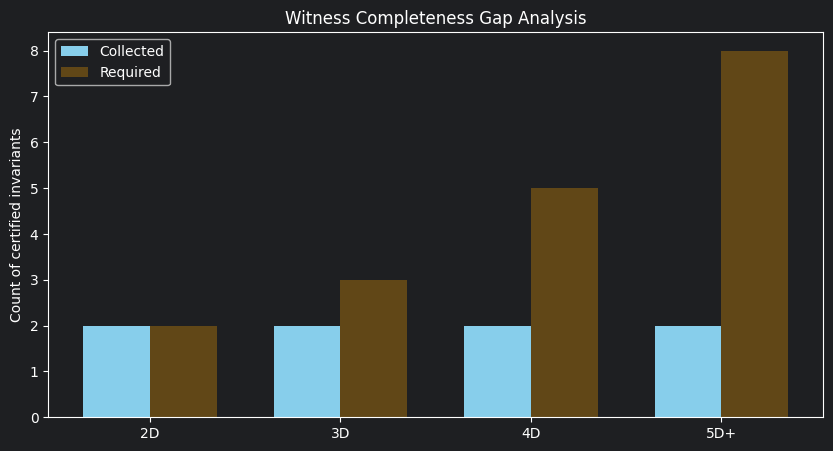

In [5]:
# Plotting the completeness (number of evidence items) vs Dimension
labels = ['2D', '3D', '4D', '5D+']
required_items = [2, 3, 5, 8] # Conceptual requirements
collected_items = [2, 2, 2, 2] # What we have currently

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, collected_items, width, label='Collected', color='skyblue')
ax.bar(x + width/2, required_items, width, label='Required', color='orange', alpha=0.3)

ax.set_ylabel('Count of certified invariants')
ax.set_title('Witness Completeness Gap Analysis')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

plt.show()

## Failure Modes

1. **Circular Evidence**: Attempting to build a witness using another witness as input can lead to recursion errors if not handled by the builder.
2. **Incompatible Evidence**: Providing a 4D intersection form for a 3D witness build will result in a `DimensionError`.
3. **Missing "Decision-Ready" flag**: If `exact=False` is present in any intermediate data, the builder will never reach `success`.


In [8]:
# Incompatible evidence does not raise here; the builder returns an inconclusive result.
res_bad = build_homeomorphism_witness(c1, c2, dim=2, m1=q_h)
print(f'Status: {res_bad.status}')
print(f'Reasoning: {res_bad.reasoning}')
print(f'Missing data: {res_bad.missing_data}')

Status: inconclusive
Reasoning: INCONCLUSIVE: 4D witness building requires both intersection forms.
Missing data: ['Both 4D intersection forms']


## Summary Checklist
- [x] Aggregated partial invariants using the `build_homeomorphism_witness` API.
- [x] Tracked status escalation from `inconclusive` to `success`.
- [x] Audited the `missing_data` list to identify next steps in the proof.
- [x] Visualized the completeness gap for different manifold dimensions.
- [x] Handled dimension mismatches and inexactness failures.

## Exercises
1. **Torus Verification**: Build a witness for two Genus-1 surfaces and verify that it achieves `success` status.
2. **5D Pipeline**: Construct a mock 5D sequence where the Wall obstruction is zero. Does the builder reach `success`?
3. **Evidence Audit**: List all items in the `evidence` field for a 4D witness and map them to Freedman's Theorem.
4. **Custom Invariants**: Research how to add a custom invariant (like a knot invariant) to the `certificates` dictionary.
5. **Batch Processing**: Write a script that takes a list of manifold pairs and returns a summary table of their witness statuses.

## Key Takeaways
- The **Witness Builder** is the "factory" for topological proofs.
- **Status Progression** ensures that we don't declare homeomorphism prematurely.
- **Missing Data** is the actionable output of an incomplete classification task.
- A **"Decision-Ready"** path is one where all dimension-specific obstructions have been evaluated.

**Ready for [17 - Embedding and Immersion: Practical Whitney](./17_embedding_and_immersion_practical_whitney.ipynb)**
